In [1]:
import pickle
import gzip
import numpy as np
import os

import preprocessing as pp
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

def load_zipped_pickle(filename):
    with gzip.open(filename, 'rb') as f:
        loaded_object = pickle.load(f)
        return loaded_object
    
def save_zipped_pickle(obj, filename):
    with gzip.open(filename, 'wb') as f:
        pickle.dump(obj, f, 2)

In [2]:
#preprocessing functions
def extract_labeled_frames(train_data, preprocessor: pp.Image_Processor):
    '''
    extracts training set and creates three channels (identity, blur, class)
    '''
    labeled_frames = []
    label_of_frames = []

    for video_data in train_data:
        video = video_data['video']        
        labels = video_data['label']
        labeled_frames_ind = video_data['frames']

        for index in labeled_frames_ind:
            frame = video[:, :, index]
            frame_label = labels[:, :, index]

            labeled_frames.append(
                preprocessor.process_image(frame)
            )
            label_of_frames.append(
                preprocessor.process_label(frame_label)
            )

    return labeled_frames, label_of_frames

class MitralValveDataset(Dataset):
    def __init__(self, frames, labels, transform=None):
        '''
        frames: list[np.ndarray]
        labels: list[np.ndarray]
        '''
        self.frames = frames
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.frames)

    def __getitem__(self, idx):
        frame = self.frames[idx]
        label = self.labels[idx]

        #transpose (height, width, channel) to (channel, height, width)
        frame = torch.tensor(np.transpose(frame, (2, 0, 1)))
        label = torch.tensor(label).reshape(1, 128, 128)

        #normalize
        frame = frame.to(torch.float32)
        label = label.to(torch.float32)
        frame[0, :, :] /= 255.0
        frame[1, :, :] /= 255.0
        frame[2, :, :] /= 3

        frame_and_label = torch.cat((frame, label), dim=0)

        if self.transform:
            frame_and_label = self.transform(frame_and_label)

        frame = frame_and_label[0:3, :, :]
        label = frame_and_label[3, :, :]

        return frame, label 

In [3]:
#Create train set

train_data = load_zipped_pickle("data/train.pkl")
test_data = load_zipped_pickle("data/test.pkl")
sample_data = load_zipped_pickle("data/sample.pkl")

In [4]:
X_train, y_train = extract_labeled_frames(train_data, pp.STANDARD_IMAGE_PROCESSOR)

augmentation_transform = transforms.Compose([
    transforms.RandomResizedCrop(size=128, scale=(0.9, 1.0)),
    transforms.RandomAffine(degrees=(-30, 30), translate=(0.05, 0.05)),   
])

train_dataset = MitralValveDataset(X_train, y_train, transform=augmentation_transform)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

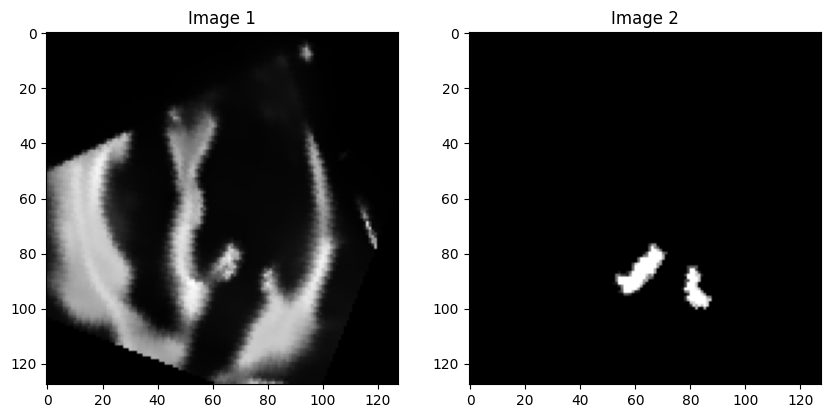

In [8]:
#visualize transformations
import torch
import matplotlib.pyplot as plt

frame, label = train_dataset[45]
gray_tensor = frame[0]

# Convert the tensors to NumPy arrays
gray_array = gray_tensor.numpy().squeeze()
label = label.numpy().squeeze()

# Display the images side by side using subplots
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray_array, cmap='gray')
plt.title('Image 1')

plt.subplot(1, 2, 2)
plt.imshow(label, cmap='gray')
plt.title('Image 2')

plt.show()

In [9]:
#Model, Loss, &Optimizer
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import segmentation_models_pytorch as smp


class IoULoss(nn.Module):
    def __init__(self):
        super(IoULoss, self).__init__()

    def forward(self, inputs, targets, smooth=1):

        inputs = F.sigmoid(inputs)

        #flatten label and prediction tensors
        inputs = inputs.view(-1)
        targets = targets.view(-1)
        
        #intersection is equivalent to True Positive count
        #union is the mutually inclusive area of all labels & predictions 
        intersection = (inputs * targets).sum()
        total = (inputs + targets).sum()
        union = total - intersection 
        
        IoU = (intersection + smooth)/(union + smooth)
                
        return 1 - IoU
    
model = smp.UnetPlusPlus(encoder_name='resnet34', encoder_depth=3, decoder_channels=(256, 128, 64), in_channels=3, classes=1)
criterion = IoULoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [10]:
#train
NUM_EPOCHS = 50

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 5 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

for _ in range(NUM_EPOCHS):
    train(train_loader, model, criterion, optimizer)

c:\Users\domil\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


loss: 0.991225  [    8/  195]
loss: 0.984580  [   48/  195]
loss: 0.982782  [   88/  195]
loss: 0.974055  [  128/  195]
loss: 0.974037  [  168/  195]
loss: 0.966834  [    8/  195]
loss: 0.963303  [   48/  195]
loss: 0.957277  [   88/  195]
loss: 0.953163  [  128/  195]
loss: 0.945917  [  168/  195]
loss: 0.930414  [    8/  195]
loss: 0.918079  [   48/  195]
loss: 0.914915  [   88/  195]
loss: 0.914331  [  128/  195]
loss: 0.883002  [  168/  195]
loss: 0.867708  [    8/  195]
loss: 0.864923  [   48/  195]
loss: 0.818165  [   88/  195]
loss: 0.806719  [  128/  195]
loss: 0.832859  [  168/  195]
loss: 0.763877  [    8/  195]
loss: 0.686033  [   48/  195]
loss: 0.680894  [   88/  195]
loss: 0.690476  [  128/  195]
loss: 0.628878  [  168/  195]
loss: 0.600368  [    8/  195]
loss: 0.573163  [   48/  195]
loss: 0.651015  [   88/  195]
loss: 0.623230  [  128/  195]
loss: 0.531680  [  168/  195]
loss: 0.561047  [    8/  195]
loss: 0.516484  [   48/  195]
loss: 0.578867  [   88/  195]
loss: 0.56

In [7]:
#save model / load model
state_dict = torch.load('unet_plus_plus.pth')
model.load_state_dict(state_dict)

<All keys matched successfully>

In [11]:
#predictions

def predict(model, video_data) -> (np.ndarray, str, Dataset):
    #add labels so I can reuse old preprocessing functions
    origin_h, origin_w, frames = video_data['video'].shape
    label = np.zeros((1, 1, frames))
    video_data['label'] = label

    #every frame is extracted
    frames_list = list(range(video_data['video'].shape[2]))
    video_data['frames'] = frames_list

    X_predict, y_label_dummy = extract_labeled_frames([video_data], pp.STANDARD_IMAGE_PROCESSOR)

    test_dataset = MitralValveDataset(X_predict, y_label_dummy)
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)    

    #prediction part
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()
    with torch.no_grad():
        predictions = []

        for X, y in test_loader:
            X, y = X.to(device), y.to(device)
            prediction = model(X)
            predictions.append(prediction.cpu())

    predictions = torch.cat(predictions, dim=0)
    predictions = F.interpolate(predictions, size=(origin_h, origin_w), mode='bilinear', align_corners=False)
    predictions = predictions >= 0
    predictions = predictions.numpy().squeeze()

    return predictions, video_data['name'], test_dataset

def create_predict_dicts(model, test_data):
    predict_dicts = []

    for video_data in test_data:
        predictions, name, _ = predict(model, video_data)
        predictions = np.transpose(predictions, (1, 2, 0))
        predict_dicts.append(
            {
                'name': name,
                'prediction': predictions
            }
        )

    return predict_dicts
        
#predictions, name, test_dataset = predict(model, test_data[0])
predict_dicts = create_predict_dicts(model, test_data)

In [38]:
save_zipped_pickle(predict_dicts, 'my_predictions.pkl')

UB7LFQKZT5 = UB7LFQKZT5
(583, 779) = (583, 779)


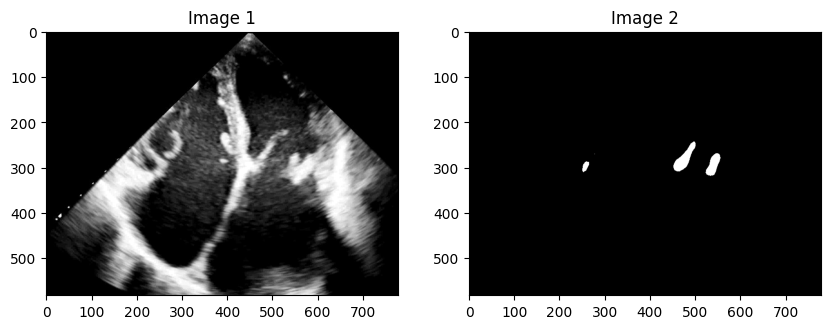

In [37]:
#visualize results
VIDEO = 19
FRAME = 34

frame = test_data[VIDEO]['video'][:, :, 0]
label = predict_dicts[VIDEO]['prediction'][:, :, 0]
print(f'{test_data[VIDEO]["name"]} = {predict_dicts[VIDEO]["name"]}')
print(f'{frame.shape} = {label.shape}')
gray_tensor = frame


# Convert the tensors to NumPy arrays
label = label.astype(int)

# Display the images side by side using subplots
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray_tensor, cmap='gray')
plt.title('Image 1')

plt.subplot(1, 2, 2)
plt.imshow(label, cmap='gray')
plt.title('Image 2')

plt.show()